# Appraisal vs Conceptual Metaphor

## Import Packages

In [1]:
import os
import pandas as pd
import re
from ast import literal_eval
from tabulate import tabulate
import random
import numpy as np
from termcolor import colored
from scipy.stats import chi2_contingency
import plotly.graph_objects as go
import plotly.express as px

## Reading and Cleaning Data

### Metaphor Annotations

In [2]:
# load in CMT annotation json and save it to a pandas dataframe
file_path = 'CMT_Jan10.json'
met_df = pd.read_json(file_path)

# load in CMT sample annotation json and save it to a pandas dataframe
file_path_sample = 'CMTS_Jan10.json'
sample_met_df = pd.read_json(file_path_sample)

In [3]:
# uploading central dataframe of file IDs
mapping_df=pd.read_csv('mapping_spreadsheet_2025_08_20.csv')
# dictionary where the CMT name is the key and the Appraisal name is the corresponding value
name_corresp_sample = dict(zip(mapping_df['CMT Sample'], mapping_df['Appraisal']))
name_corresp_proj = dict(zip(mapping_df['CMT Project'], mapping_df['Appraisal']))

In [4]:
# cleaning up file names in project dataset
met_df['filename'] = met_df.apply(lambda row: re.sub(r"^[^_]*-", '', row.file_upload), axis=1)
met_df['filename'] = met_df.apply(lambda row: re.sub(r"_fixed", '', row.filename[:-4].lower()), axis=1)
# changing file names to match Appraisal file names
met_df['filename'] = met_df.apply(lambda row: name_corresp_proj[row.filename], axis=1)
met_df['filename'] = met_df.apply(lambda row: re.sub(r"aboriginal", 'indigenous', row.filename), axis=1)

# cleaning up file names in sample dataset
sample_met_df['filename'] = sample_met_df.apply(lambda row: re.sub(r"^[^_]*-", '', row.file_upload), axis=1)
sample_met_df['filename'] = sample_met_df.apply(lambda row: re.sub(r"_fixed", '', row.filename[:-4].lower()), axis=1)
# changing file names to match Appraisal file names 
sample_met_df['filename'] = sample_met_df.apply(lambda row: re.sub(r"aboriginal", 'indigenous', row.filename), axis=1)
sample_met_df['filename'] = sample_met_df.apply(lambda row: name_corresp_sample[row.filename], axis=1)
sample_met_df['filename'] = sample_met_df.apply(lambda row: re.sub(r"aboriginal", 'indigenous', row.filename), axis=1)

# COMBINING W SAMPLE
met_df = pd.concat([met_df, sample_met_df]).reset_index()
# extracting labels from the annotations column
met_df['labels'] = met_df.apply(lambda row: row.annotations[0]['result'], axis=1)

In [5]:
# creating a dictionary of metaphor labels, where each key is a filename
met_labels = {}
for name in met_df['filename'].unique():
    # creating a new dataframe only containing labels corresponding to one file
    new_df = met_df[met_df['filename']==name][['filename', 'labels']].reset_index()
    # creating a list to save the labels in 
    labels_dic = {}
    for el in new_df['labels'][0]:
        # adding labels to the label list 
        if el['from_name']=='source':
            start = el['value']['start']
            end = el['value']['end']
            for source in el['value']['taxonomy']:
                try: 
                    labels_dic[source[0]].append([start,end])
                except KeyError: 
                    labels_dic[source[0]] = [[start,end]]
    # saving the dic of labels to the dictionary of filenames
    met_labels[name] = labels_dic

In [6]:
len(met_labels.keys())

1043

In [7]:
# unique labels
unique_labels = {}
for key in met_labels.keys():
    lst = []
    for val in met_labels[key].values():
        for el in val:
            if el not in lst:
                lst.append(el)
    unique_labels[key] = lst

In [8]:
# count unique labels
cnt = 0
for v in unique_labels.values():
    cnt+=len(v)
print(cnt)

4384


In [9]:
# all the labels in a file (counting units with multiple labels multiple times)
all_labels = {}

for k in met_labels.keys():
    all_labels[k] = []

for k,v in met_labels.items():
    for inds in v.values():
        for ind in inds:
            all_labels[k].append(ind)

In [10]:
# counting total labels
cnt = 0
for v in all_labels.values():
    cnt+=len(v)
print(cnt)

5586


In [11]:
# source domain list
sd_list = []
for file in list(met_labels.keys()):
    for sd in met_labels[file].keys():
        if sd not in sd_list:
            sd_list.append(sd)
# counting source domains used in project
len(sd_list)

243

In [12]:
# dictionary where each key is a source domain and each value is a nested dictionary, 
# where the keys are file names and the values are lists of lists (containing label start and end indices)
sd_dict = {}
for fig in sd_list:
    sd_dict[fig] = {}
    for file in list(met_labels.keys()):
        try:
            sd_dict[fig][file] = met_labels[file][fig]
        except KeyError:
            sd_dict[fig][file] = []
            pass

### Appraisal Annotations

In [13]:
def extractor(dic, col, txt):
    '''
    takes dic (a dictionary of dataframes), col (a string corresponding to column name), 
    and txt (a string containing the label type to extract) as input
    returns a dictionary with the same keys as dic, where the values are lists of label lists (e.g., [[1,7],[9,15]])
    '''
    # creating a dictionary of labels, where each key is a filename and each value is a list of labels
    labels_dic = {}
    # looping through all the keys and values in the input dictionary
    for name, df in dic.items():
        # creating an empty list of labels labels
        labels_list = []
        # dropping rows with no labels 
        cleaned_df = df[df[col] != '_'][['indices', col]].dropna()
        # if there are no labels, assigns an empty list
        if len(cleaned_df[col]) == 0:
            labels_dic[name]=labels_list
        else:
            # extracting rows that contain the input txt in the label column
            dic_labels = cleaned_df[cleaned_df[col].str.contains(txt)][col].unique()
            for d in dic_labels:
                cleaned_df_v2 = cleaned_df[cleaned_df[col]==d]
                # adding labels to the list of labels
                new_dic = {}
                new_dic[d] = {}
                # setting unreasonable values
                new_dic[d]['lowest'] = 1000000000
                new_dic[d]['highest'] = -1
                for r in cleaned_df_v2.indices:
                    # splitting the index string into a list
                    ind = [int(x) for x in r.split('-')]
                    # updating lowest index
                    if ind[0] < new_dic[d]['lowest']:
                        new_dic[d]['lowest'] = ind[0]
                    # updating highest index
                    if ind[1] > new_dic[d]['highest']:
                        new_dic[d]['highest'] = ind[1]
                # adding labels to list of labels
                labels_list.append([new_dic[d]['lowest'], new_dic[d]['highest']])
            # assigning list of labels to filename in the label dictionary
            labels_dic[name]=labels_list
    return labels_dic

In [14]:
# creating a dictionary of appraisal annotation dataframes, where each key is a file name
appraisal_dict = {}

# list of file names in the metaphor annotations
filenames = met_labels.keys()

# looping through each file name in the metaphor annotations 
for name in filenames:
    # finding the corresponding folder id for appraisal
    folder_id = name.replace('indigenous', 'aboriginal')
    # setting folder path
    path = 'SOCC/annotated/Appraisal/Appraisal_annotations/curation/' + folder_id
    try:
        # loading in appraisal annotations in folders that end with '.txt'
        filename = os.listdir(path + '.txt')[0]
        # reading and saving the annotations to a pandas dataframe
        try:
            df = pd.read_csv(path + '.txt/' + filename, sep = '\t', header = None, 
                             skiprows=5, names=['no.','indices','text','attitude','label','polarity'])
        except:
            df = pd.read_csv(path + '.txt/' + filename, sep = '\t', header = None, 
                             skiprows=6, names=['no.','indices','text','attitude','label','polarity'])
        # saving the dataframe to the appraisal dictionary 
        appraisal_dict[name] = df
    except:
        # loading in appraisal annotations in folders that end with '.tsv'
        filename = os.listdir(path + '.tsv')[0]
        # reading and saving the annotations to a pandas dataframe
        try:
            df = pd.read_csv(path + '.tsv/' + filename, sep = '\t', header = None, skiprows=5, 
                             names=['no.','indices','text','attitude','label','polarity'])
        except:
            df = pd.read_csv(path + '.tsv/' + filename, sep = '\t', header = None, skiprows=6, 
                             names=['no.','indices','text','attitude','label','polarity'])
        # saving the dataframe to the appraisal dictionary
        appraisal_dict[name] = df

In [15]:
# cleaning labels in the label and attitude columns by removing the annotation before the '|'
for filename in appraisal_dict.keys():
    appraisal_dict[filename]['label_final']=appraisal_dict[filename].apply(lambda row: str(row.label).split('|')[-1], axis=1)
    appraisal_dict[filename]['attitude_final']=appraisal_dict[filename].apply(lambda row: str(row.attitude).split('|')[-1], axis=1)

In [16]:
# confirming that files all match
print(len(unique_labels.keys()), len(appraisal_dict.keys()), 
      len(set(list(unique_labels.keys()) + list(appraisal_dict.keys()))),
      set(list(unique_labels.keys())) - set(list(appraisal_dict.keys())),
      set(list(appraisal_dict.keys())) - set(list(unique_labels.keys())))

1043 1043 1043 set() set()


In [17]:
# a dictionary where every key is a file name and every value is a list of the character indices icluded in the negative labels 
neg_labels = extractor(appraisal_dict, 'label_final', 'neg')
# a dictionary where every key is a file name and every value is a list of the character indices included in the positive labels 
pos_labels = extractor(appraisal_dict, 'label_final', 'pos')
# a dictionary where every key is a file name and every value is a list of the character indices included in the Appreciation labels 
appr_labels = extractor(appraisal_dict, 'attitude_final', 'Appreciation')
# a dictionary where every key is a file name and every value is a list of the character indices included in the Judgement labels 
judg_labels = extractor(appraisal_dict, 'attitude_final', 'Judgment') # note spelling
# a dictionary where every key is a file name and every value is a list of the character indices included in the Affect labels 
aff_labels = extractor(appraisal_dict, 'attitude_final', 'Affect')

## Comparison 
### what are we measuring? how?
We are deriving ten metrics to measure the overlap between metaphor and Appraisal and, within Appraisal, between negative evaluation and metaphor. The first five take the metaphor annotations as their starting point and calculate how many of those were also labelled in the Appraisal annotations, broken down into subcategories of Appraisal: 
1. Percentage of metaphorical units that are labelled as Affect 
2. Percentage of metaphorical units that are labelled as Judgement  
3. Percentage of metaphorical units that are labelled as Appreciation  
4. Percentage of metaphorical units that are labelled as positive 
5. Percentage of metaphorical units that are labelled as negative 
The next five metrics take an Appraisal label as their starting point and calculate what percentage of those have metaphor labels:
1. Percentage of Affect units that are labelled as metaphorical  
2. Percentage of Judgement units that are labelled as metaphorical 
3. Percentage of Appreciation units that are labelled as metaphorical 
4. Percentage of positive units that are labelled as metaphorical 
5. Percentage of negative units that are labelled as negative 
For (1), we first go through each label in the metaphor annotations, and check if 30% of the characters show up in a Affect label. If they do, we say that that metaphorical unit is labelled as Affect. We then calculate the percentage of Affect metaphorical units by dividing the number of metaphors that are labelled as Affect by the number of units labelled as metaphorical overall. The other metrics follow a similar methodology. 

In [18]:
def overlap_calculator_helper(dic1, dic2):
    '''
    returns a list containing the percentage and number of dic1 units that are labelled in dic2
    '''
    # setting counter for number of labels overall
    dic1_total_labels, dic2_total_labels = 0, 0
    
    # number of labels in each dic that overlap (e.g., if dic1 has labels [1,3] and [4,9] for a file 
    # and dic2 has a label [1,9] for the same file, then dic1 has two overlapping labels with dic2 
    # and dic2 has 1 overlapping label with dic1)
    overall_overlap_cnt_dic1, overall_overlap_cnt_dic2 = 0, 0
    
    for file in list(dic1.keys()):
        # initializing overlap count for each file in each dictionary; setting it to 0
        overlap_cnt_dic1, overlap_cnt_dic2 = 0, 0

        # loops through each label list in the list of list of labels corresponding to each key in the dictionary 
        for label_dic1 in dic1[file]:
                # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
                label_dic1_characters = set(list(range(label_dic1[0],label_dic1[1]+1)))
                # loops through the labels in the second dictionary for the same key
                for label_dic2 in dic2[file]:
                    # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
                    label_dic2_characters = set(list(range(label_dic2[0],label_dic2[1]+1)))
                    # variable representing the characters included in both labels (intersection)
                    overlap = label_dic1_characters & label_dic2_characters
                    # variable representing the elements included in either label (union)
                    universe = label_dic2_characters | label_dic2_characters
                    
                    # calculating overlap % if more than one element exists in both labels 
                    # setting overlap to > 1 accounts for punctuation, etc.
                    if len(overlap) > 1:
                        # the percentage of the first label that is included in the second label
                        result_dic1 = float(len(overlap)) / len(label_dic1_characters) * 100
                        # if at least 30% of the first label is included in the second label, it counts as overlap for the first label
                        if result_dic1 >= 30:
                            overlap_cnt_dic1+=1
                            overall_overlap_cnt_dic1+=1
                            break

        # adding to counter of total labels for dic1
        dic1_total_labels = dic1_total_labels + len(dic1[file])
        
    # percentage of dic1 units that are labelled in dic2
    return [overall_overlap_cnt_dic1/dic1_total_labels * 100,overall_overlap_cnt_dic1]
    
def overlap_calculator(dic1, dic2):
    '''
    returns a dictionary containing the percentage of dic1 units that are labelled in dic2 and 
    the percentage of dic2 units that are labelled in dic1, the total number of dic1 units labelled in dic2,
    and the total number of dic2 units labelled in dic1
    '''
    return {'percentage of dic1 units that are labelled in dic2': overlap_calculator_helper(dic1, dic2)[0],
            'percentage of dic2 units that are labelled in dic1': overlap_calculator_helper(dic2, dic1)[0],
            'overall_overlap_cnt_dic1': overlap_calculator_helper(dic1, dic2)[1],
            'overall_overlap_cnt_dic2': overlap_calculator_helper(dic2, dic1)[1]}

In [19]:
overlap_percentage_pos = overlap_calculator(pos_labels, unique_labels).values()
overlap_percentage_neg = overlap_calculator(neg_labels, unique_labels).values()
overlap_percentage_appr = overlap_calculator(appr_labels, unique_labels).values()
overlap_percentage_aff = overlap_calculator(aff_labels, unique_labels).values()
overlap_percentage_judg = overlap_calculator(judg_labels, unique_labels).values()

print(f'percentage of CMT units that are labelled as X')
print(tabulate([['Positive', list(overlap_percentage_pos)[3], round(list(overlap_percentage_pos)[1],2)], 
                ['Negative', list(overlap_percentage_neg)[3], round(list(overlap_percentage_neg)[1],2)],
                ['Appreciation', list(overlap_percentage_appr)[3], round(list(overlap_percentage_appr)[1],2)], 
                ['Affect', list(overlap_percentage_aff)[3], round(list(overlap_percentage_aff)[1],2)],
                ['Judgement', list(overlap_percentage_judg)[3], round(list(overlap_percentage_judg)[1],2)]], headers=['X', 'Count', '%']))

percentage of CMT units that are labelled as X
X               Count      %
------------  -------  -----
Positive          398   9.08
Negative         1219  27.81
Appreciation      855  19.5
Affect             15   0.34
Judgement         787  17.95


In [20]:
overlap_percentage_pos = overlap_calculator(pos_labels, unique_labels).values()
overlap_percentage_neg = overlap_calculator(neg_labels, unique_labels).values()
overlap_percentage_appr = overlap_calculator(appr_labels, unique_labels).values()
overlap_percentage_aff = overlap_calculator(aff_labels, unique_labels).values()
overlap_percentage_judg = overlap_calculator(judg_labels, unique_labels).values()

print(f'percentage of X labels that are labelled as CMT')
print(tabulate([['Positive', list(overlap_percentage_pos)[2], round(list(overlap_percentage_pos)[0],2)], 
                ['Negative', list(overlap_percentage_neg)[2], round(list(overlap_percentage_neg)[0],2)],
                ['Appreciation', list(overlap_percentage_appr)[2], round(list(overlap_percentage_appr)[0],2)], 
                ['Affect', list(overlap_percentage_aff)[2], round(list(overlap_percentage_aff)[0],2)],
                ['Judgement', list(overlap_percentage_judg)[2], round(list(overlap_percentage_judg)[0],2)]], headers=['X', 'Count', '%']))

percentage of X labels that are labelled as CMT
X               Count      %
------------  -------  -----
Positive          296  46.11
Negative          857  43.09
Appreciation      595  44.67
Affect             16  20.51
Judgement         559  43.57


We also measure the percentage of CMT labels that overlap with Attitude labels and the percentage of Attitude labels that overlap with CMT labels.


In [21]:
# measuring the percentage of CMT labels that overlap with Attitude labels and the percentage of Attitude labels that overlap with CMT labels

# a dictionary where every key is a file name and every value is a list of the character indices included in the Appreciation labels 
appr_labels = extractor(appraisal_dict, 'attitude_final', 'Appreciation')
# a dictionary where every key is a file name and every value is a list of the character indices included in the Judgement labels 
judg_labels = extractor(appraisal_dict, 'attitude_final', 'Judgment') # note spelling
# a dictionary where every key is a file name and every value is a list of the character indices included in the Affect labels 
aff_labels = extractor(appraisal_dict, 'attitude_final', 'Affect')

# dictionary of Attitude labels, based on Appreciation, Judgement, and Affect  
att_labels = {}
for p in list(appr_labels.keys()):
    att_labels[p] = appr_labels[p].copy()
for j in list(judg_labels.keys()):
    if judg_labels[j] != []:
        att_labels[j] = att_labels[j] + judg_labels[j]
for f in list(aff_labels.keys()):
    if aff_labels[f] != []:
        att_labels[f] = att_labels[f] + aff_labels[f]

overlap_calculator(att_labels, unique_labels)

{'percentage of dic1 units that are labelled in dic2': 43.44597103601931,
 'percentage of dic2 units that are labelled in dic1': 34.96806569343065,
 'overall_overlap_cnt_dic1': 1170,
 'overall_overlap_cnt_dic2': 1533}

The following block of code answers the question, given evaluative language, which source domains appear more frequently than others?

In [22]:
# given Attitude, these are the most common overlapping CMT labels (and % of overlap)
mst_common_eval = []
cnt = 0
for sd in sd_dict.keys():
    over = overlap_calculator(att_labels, sd_dict[sd])['percentage of dic1 units that are labelled in dic2']
    if over > 1:
        print(sd, round(over, 2))
        mst_common_eval.append(sd)

Crime 1.49
Transferring an Object 3.19
Container(s) 3.23
Preventing movement/motion 1.26
Game 1.26
Possession(s) 1.3
Force 1.0
Object(s) 1.08
Motion 1.11
Constructed Object 1.52


## Chi-squared Test
using a chi-squared test, we answer the question of which source domains are more or less evaluative than others, and do they express positive or negative evaluation. 

In [23]:
def chi_helper(dic1, dic2):
    '''
    returns a list of the number of dic1 units in total and the number that are labelled in dic2
    '''
    # setting counter for number of labels overall
    dic1_total_labels = 0
    
    # number of labels in dic1 that overlap with dic 2 (e.g., if dic1 has labels [1,3] and [4,9] for a file 
    # and dic2 has a label [1,9] for the same file, then dic1 has two overlapping labels with dic2 )
    overall_overlap_cnt_dic1 = 0
    
    for file in list(dic1.keys()):
        # initializing overlap count for each file in dictionary 1; setting it to 0
        overlap_cnt_dic1 = 0

        # loops through each label list in the list of list of labels corresponding to each key in the dictionary 
        for label_dic1 in dic1[file]:
                # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
                label_dic1_characters = set(list(range(label_dic1[0],label_dic1[1]+1)))
                # loops through the labels in the second dictionary for the same key
                for label_dic2 in dic2[file]:
                    # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
                    label_dic2_characters = set(list(range(label_dic2[0],label_dic2[1]+1)))
                    # variable representing the characters included in both labels (intersection)
                    overlap = label_dic1_characters & label_dic2_characters
                    # variable representing the elements included in either label (union)
                    universe = label_dic2_characters | label_dic2_characters
                    
                    # calculating overlap % if more than one element exists in both labels 
                    # setting overlap to > 1 accounts for punctuation, etc.
                    if len(overlap) > 1:
                        # the percentage of the first label that is included in the second label
                        result_dic1 = float(len(overlap)) / len(label_dic1_characters) * 100
                        # if at least 30% of the first label is included in the second label, it counts as overlap for the first label
                        if result_dic1 >= 30:
                            overlap_cnt_dic1+=1
                            overall_overlap_cnt_dic1+=1
                            break

        # adding to counter of total labels for dic1
        dic1_total_labels = dic1_total_labels + len(dic1[file])
        
    # number of labels in dic 1 that overlap with dic 2 and number of labels in dic 1
    return [overall_overlap_cnt_dic1, dic1_total_labels]

In [24]:
# dataframe where each row represents one source domains with columns representing the number of negative evals overlapping
# with that source domain, the total number of labels for that source domain, and the difference between them
chi_df = pd.DataFrame(sd_dict.keys(), columns=['SD'])
chi_df['Negative'] = chi_df.apply(lambda row: chi_helper(sd_dict[row.SD], neg_labels)[0], axis=1)
chi_df['Total'] = chi_df.apply(lambda row: chi_helper(sd_dict[row.SD], neg_labels)[1], axis=1)
chi_df['Not Negative'] = chi_df['Total']-chi_df['Negative']

In [25]:
# CMT labels where a statistically significant proportion (<0.05) overlap with negative evaluation 
vip_sd_neg = []
for source in sd_dict.keys():
    # chi-squared test
    neg_A = chi_df[chi_df.SD==source].Negative
    not_neg_A = chi_df[chi_df.SD==source]['Not Negative']
    neg_B = chi_df.Negative.sum() - chi_df[chi_df.SD==source].Negative
    not_neg_B = chi_df['Not Negative'].sum() - chi_df[chi_df.SD==source]['Not Negative']
    table = np.array([[neg_A, not_neg_A], [neg_B, not_neg_B]])
    res = chi2_contingency(table)
    if res.pvalue < 0.05:
        print(source, res.pvalue)
        vip_sd_neg.append(source)

Crime 0.00014978823598315062
Physical Properties 0.007375616457375282
Function(ing)/Functionality 0.016504034796837014
Moving Object 0.02021636940612486
Linked Objects 0.01174624885721494
Destruction 0.04282836240377194
Machine/Mechanism 0.0041202889376138465
Cover 0.04891677743672402
Cause, Causation 0.012877616054888767
Education 0.0029047769702738326
Goal 0.039285585231386054
Adversity 0.019565293524207678
Body Of Water 0.029238658964362417
Disposables/Garbage 4.996813820982585e-05
Line 0.04730571259776832
Religion 0.03897125269236875
Kinship 0.024626163344624648
Competition 0.01692903336475913
Race 0.041102103115832345
Story 0.000900801582490213
Belief(s) 0.007201894602425499
Sleep 0.007198975102146317


In [26]:
# dataframe where each row represents one source domains with columns representing the number of negative evals overlapping
# with that source domain, the total number of labels for that source domain, and the difference between them
chi_df['Positive'] = chi_df.apply(lambda row: chi_helper(sd_dict[row.SD], pos_labels)[0], axis=1)
chi_df['Total'] = chi_df.apply(lambda row: chi_helper(sd_dict[row.SD], pos_labels)[1], axis=1)
chi_df['Not Positive'] = chi_df['Total']-chi_df['Positive']

In [27]:
# CMT labels where a statistically significant proportion (<0.05) overlap with positive evaluation 
vip_sd_pos = []
for source in sd_dict.keys():
    # chi-squared test
    pos_A = chi_df[chi_df.SD==source].Positive
    not_pos_A = chi_df[chi_df.SD==source]['Not Positive']
    pos_B = chi_df.Positive.sum() - chi_df[chi_df.SD==source].Positive
    not_pos_B = chi_df['Not Positive'].sum() - chi_df[chi_df.SD==source]['Not Positive']
    table = np.array([[pos_A, not_pos_A], [pos_B, not_pos_B]])
    res = chi2_contingency(table)
    if res.pvalue < 0.05:
        print(source, res.pvalue)
        vip_sd_pos.append(source)

Transferring an Object 0.00593271313158758
Preventing movement/motion 0.0024474874655426777
Possession(s) 0.01713896167572223
Plant 0.002417151315018576
Vertical Scale 0.036960166665068725
Problem Solving 0.0002556310038883078
Change 0.0003552459052650851
Royalty 0.003877760802412987


In [28]:
# adding a column for the number of source domains that are not labelled as positive or negative evaluation
chi_df['Not Evaluative'] = chi_df['Total'] - chi_df['Negative'] - chi_df['Positive']

In [29]:
# rows with count > 20
chi_df[chi_df.Total>20]

,SD,Negative,Total,Not Negative,Positive,Not Positive,Not Evaluative
3,Crime,38,79,41,2,77,39
4,Transferring an Object,69,214,145,30,184,115
5,Container(s),96,378,282,28,350,254
6,Location,19,66,47,8,58,39
7,Tool,14,31,17,1,30,16
...,...,...,...,...,...,...,...
140,Time,3,24,21,1,23,20
145,Belief(s),12,21,9,1,20,8
156,Entertainment,9,28,19,3,25,16
162,Communication,14,71,57,7,64,50


In [30]:
# source domains with count > 20 and a statistically significant proportion (<0.05) overlap with negative evaluation
neg_df = chi_df[chi_df.SD.isin(vip_sd_neg)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']]
neg_df

C:\Users\romha\AppData\Local\Temp\ipykernel_19868\116796088.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neg_df = chi_df[chi_df.SD.isin(vip_sd_neg)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']]


,SD,Negative,Positive,Not Evaluative,Total
3,Crime,38,2,39,79
18,Physical Properties,20,11,87,118
23,Moving Object,12,9,55,76
27,Destruction,14,0,16,30
41,Machine/Mechanism,20,2,18,40
46,Cover,23,4,29,56
47,"Cause, Causation",1,2,22,25
52,Education,23,3,21,47
67,Adversity,14,0,14,28
79,Disposables/Garbage,19,3,8,30


In [31]:
# source domains with count > 20 and a statistically significant proportion (<0.05) overlap with positive evaluation
pos_df = chi_df[chi_df.SD.isin(vip_sd_pos)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']]
pos_df

C:\Users\romha\AppData\Local\Temp\ipykernel_19868\4076839637.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pos_df = chi_df[chi_df.SD.isin(vip_sd_pos)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']]


,SD,Negative,Positive,Not Evaluative,Total
4,Transferring an Object,69,30,115,214
16,Preventing movement/motion,21,14,38,73
21,Possession(s),31,19,78,128
35,Plant,13,9,16,38
101,Vertical Scale,6,6,16,28
109,Problem Solving,2,7,12,21


## Plots

In [32]:
# Marimekko plot for the ten most common source domains

top10 = ['Container(s)', 'Transferring an Object', 'Object(s)', 'Motion', 'Body', 'Possession(s)', 'Physical Properties', 'Competition', 'Constructed Object', 'Game'] 
top10_df = chi_df[chi_df.SD.isin(top10)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']].sort_values('Total', ascending=False)
df = top10_df

df["Neg_pct"] = df.Negative / df.Total
df["Pos_pct"] = df.Positive / df.Total
df["Not_pct"] = df["Not Evaluative"] / df.Total

labels = list(df.SD)
widths = np.array(df.Total)

data = {
    'Negative': list(df['Neg_pct']*100),
    'Positive': list(df['Pos_pct']*100)#,
#    "Not Evaluative": list(df['Not_pct']*100)
}

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Negative',
    y=data['Negative'],
    x=np.cumsum(widths)-widths,
    width=widths,
    offset=0,
    marker_color='indianred',
    customdata=np.transpose([labels, widths*data['Negative']]),
    hovertemplate="<br>".join([
        "label: %{customdata[0]}",
        "percent: %{y}"
    ])
))

fig.add_trace(go.Bar(
    name='Positive',
    y=data['Positive'],
    x=np.cumsum(widths)-widths,
    width=widths,
    offset=0,
    marker_color='cadetblue',
    customdata=np.transpose([labels, widths*data['Positive']]),
    textposition="inside",
    textangle=0,
    textfont_color="white",
    hovertemplate="<br>".join([
        "label: %{customdata[0]}",
        "percent: %{y}"
    ])
))

fig.update_xaxes(
    tickvals=np.cumsum(widths)-widths/2,
    ticktext= ["%s" % l for l in labels]
)

fig.update_xaxes(range=[0,widths.sum()])
fig.update_yaxes(range=[0,100])

fig.update_layout(
    title_text="Overlap with polarity for ten most frequent source domains",
    xaxis=dict(
        title="Source domains"),
    yaxis=dict(title="Percentage of overlap"),
    barmode="stack",
    uniformtext=dict(mode="hide", minsize=10),
)

fig.show()
fig.write_html("top10polarity.html")

C:\Users\romha\AppData\Local\Temp\ipykernel_19868\1186031945.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top10_df = chi_df[chi_df.SD.isin(top10)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']].sort_values('Total', ascending=False)


In [33]:
# Marimekko plot for the ten source domains that are most commonly found in units labelled for Attitude
mst_common_df = chi_df[chi_df.SD.isin(mst_common_eval)][chi_df.Total>20][['SD','Negative', 'Positive', 'Not Evaluative', 'Total']].sort_values('Total', ascending=False)

df = mst_common_df

df["Neg_pct"] = df.Negative / df.Total
df["Pos_pct"] = df.Positive / df.Total
df["Not_pct"] = df["Not Evaluative"] / df.Total

labels = list(df.SD)
widths = np.array(df.Total)

data = {
    'Negative': list(df['Neg_pct']*100),
    'Positive': list(df['Pos_pct']*100)#,
#    "Not Evaluative": list(df['Not_pct']*100)
}

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Negative',
    y=data['Negative'],
    x=np.cumsum(widths)-widths,
    width=widths,
    offset=0,
    marker_color='indianred',
    customdata=np.transpose([labels, widths*data['Negative']]),
    hovertemplate="<br>".join([
        "label: %{customdata[0]}",
        "percent: %{y}"
    ])
))

fig.add_trace(go.Bar(
    name='Positive',
    y=data['Positive'],
    x=np.cumsum(widths)-widths,
    width=widths,
    offset=0,
    marker_color='cadetblue',
    customdata=np.transpose([labels, widths*data['Positive']]),
    textposition="inside",
    textangle=0,
    textfont_color="white",
    hovertemplate="<br>".join([
        "label: %{customdata[0]}",
        "percent: %{y}"
    ])
))

fig.update_xaxes(
    tickvals=np.cumsum(widths)-widths/2,
    ticktext= ["%s" % l for l in ['Preventing <br>movement/motion' if x=='Preventing movement/motion' else x for x in labels]],
#    tickangle = 30
)

fig.update_xaxes(range=[0,widths.sum()])
fig.update_yaxes(range=[0,100])

fig.update_layout(
    title_text="Overlap with polarity for the ten most common source domains in evaluative expressions",
    xaxis=dict(
        title="Source domains"),
    yaxis=dict(title="Percentage of overlap"),
    barmode="stack",
    uniformtext=dict(mode="hide", minsize=10),
)

fig.show()
fig.write_html("top10eval.html")

C:\Users\romha\AppData\Local\Temp\ipykernel_19868\661832156.py:2: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



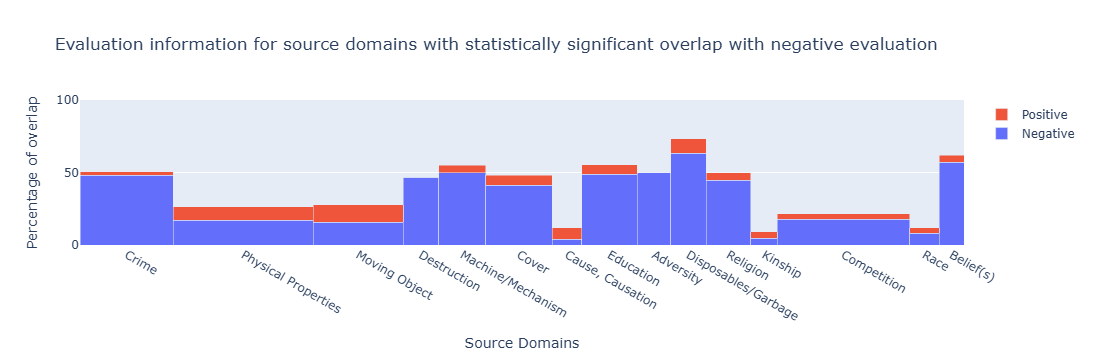

In [39]:
# Marimekko plot for source domains that overlap significantly with negative evaluation
df = neg_df

df["Neg_pct"] = df.Negative / df.Total
df["Pos_pct"] = df.Positive / df.Total

labels = list(df.SD)
widths = np.array(df.Total)

data = {
    "Negative": list(df['Neg_pct']*100),
    "Positive": list(df['Pos_pct']*100)
}

fig = go.Figure()
for key in data:
    fig.add_trace(go.Bar(
        name=key,
        y=data[key],
        x=np.cumsum(widths)-widths,
        width=widths,
        offset=0,
        customdata=np.transpose([labels, widths*data[key]]),
        hovertemplate="<br>".join([
            "label: %{customdata[0]}",
            "percent: %{y}"
        ])
    ))

fig.update_xaxes(
    tickvals=np.cumsum(widths)-widths/2,
    ticktext= ["%s" % l for l in labels]
)

fig.update_xaxes(range=[0,widths.sum()])
fig.update_yaxes(range=[0,100])

fig.update_layout(
    title_text="Evaluation information for source domains with statistically significant overlap with negative evaluation",
    xaxis=dict(
        title="Source Domains"),
    yaxis=dict(title="Percentage of overlap"),
    barmode="stack",
    uniformtext=dict(mode="hide", minsize=10),
)

fig.show()
fig.write_html("negative.html")

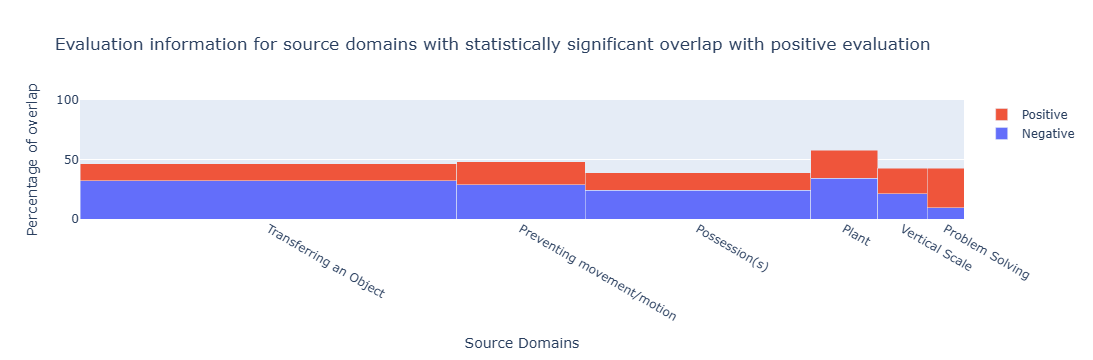

In [40]:
# Marimekko plot for source domains that overlap significantly with positive evaluation
df = pos_df

df["Neg_pct"] = df.Negative / df.Total
df["Pos_pct"] = df.Positive / df.Total

labels = list(df.SD)
widths = np.array(df.Total)

data = {
    "Negative": list(df['Neg_pct']*100),
    "Positive": list(df['Pos_pct']*100)
}

fig = go.Figure()
for key in data:
    fig.add_trace(go.Bar(
        name=key,
        y=data[key],
        x=np.cumsum(widths)-widths,
        width=widths,
        offset=0,
        customdata=np.transpose([labels, widths*data[key]]),
        hovertemplate="<br>".join([
            "label: %{customdata[0]}",
            "percent: %{y}"
        ])
    ))

fig.update_xaxes(
    tickvals=np.cumsum(widths)-widths/2,
    ticktext= ["%s" % l for l in labels]
)

fig.update_xaxes(range=[0,widths.sum()])
fig.update_yaxes(range=[0,100])

fig.update_layout(
    title_text="Evaluation information for source domains with statistically significant overlap with positive evaluation",
    xaxis=dict(
        title="Source Domains"),
    yaxis=dict(title="Percentage of overlap"),
    barmode="stack",
    uniformtext=dict(mode="hide", minsize=10),
)


fig.show()
fig.write_html("positive.html")

## Overlap Examples

In [36]:
# selecting 500 files at random to check for overlap between metaphor and appraisal
random.seed(10)
example_files = random.sample(list(filenames), 500)

In [37]:
def overlap_examples(dic1, dic2, examples):
    '''
    given two dictionaries and a list of file names, prints the names of the files that have overlapping labels, the text of the files, 
    each label, and the overlapping segment
    '''
    for file in examples:
        for label_dic1 in dic1[file]:
            # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
            label_dic1_characters = set(list(range(label_dic1[0],label_dic1[1]+1)))
            # loops through the labels in the second dictionary for the same key
            for label_dic2 in dic2[file]:
                # creating a set of the characters contained in the indices (e.g., [1,5] -> [1,2,3,4,5])
                label_dic2_characters = set(list(range(label_dic2[0],label_dic2[1]+1)))
                # variable representing the characters included in both labels (intersection)
                overlap = label_dic1_characters & label_dic2_characters
                # variable representing the elements included in either label (union)
                universe = label_dic2_characters | label_dic2_characters
                
                # calculating overlap % if more than one element exists in both labels 
                # setting overlap to > 1 accounts for punctuation, etc.
                if len(overlap) > 1:
                    # the percentage of the first label that is included in the second label
                    result_dic1 = float(len(overlap)) / len(label_dic1_characters) * 100
                    # the percentage of the second label that is included in the first label
                    result_dic2 = float(len(overlap)) / len(label_dic2_characters) * 100
                    # if at least 30% of one label is included in the other label, it counts as overlap
                    if result_dic1 >= 30 or result_dic2 >= 30:
                        # increasing counters by 1
                        text = met_df[met_df['filename']==file].reset_index().data[0]['text']
                        print('file name: {}\n text: {}\n metaphor label: {}\n appraisal label: {}\n overlap: {}'.format(file, 
                              text,
                              text[label_dic1[0]:label_dic1[1]],
                              text[label_dic2[0]:label_dic2[1]],
                              text[list(overlap)[0]: list(overlap)[-1]]))

In [38]:
print("'race' metaphor and positive overlap examples:")
overlap_examples(sd_dict['Race'], pos_labels, example_files) 

'race' metaphor and positive overlap examples:
file name: hillary_82
 text: Sarah Palin might very well have been the first female president, had she decided to run. Would you have voted for her though?Thought so.
 metaphor label: had she decided to run
 appraisal label: might very well have been the first female president, had she decided to run
 overlap: had she decided to run
